In [160]:
import os
import sys
import numpy as np
import pandas as pd
import geopandas as gpd
from matplotlib import pyplot as plt
from rapidfuzz import fuzz
from itertools import combinations
from shapely.geometry import MultiPoint
from geopy import distance
from shapely import Point

from rapidfuzz import fuzz
from itertools import combinations
from shapely.geometry import multipoint
from scipy.spatial.distance import pdist

# NWT Databases

## OROGO

In [161]:
# OROGO database
OROGO = pd.read_csv('source_data/wells/NWT/orogo-well-status-updated-2026-04-10.csv').drop(columns=['NAD 27 Lat','NAD 27 Long','Unnamed: 16','Unnamed: 17']).dropna(how='all')
OROGO = gpd.GeoDataFrame(data=OROGO,geometry=gpd.points_from_xy(x=OROGO['NAD_83_LongDD'],y=OROGO['NAD_83_LatDD']),crs='NAD1983')
OROGO['Name'] = OROGO['Well Name'].str.upper()
OROGO = OROGO.set_index('Name',drop=False)
OROGO = OROGO.drop(columns='geometry')
OROGO[['y','x']] = OROGO[['NAD_83_LatDD', 'NAD_83_LongDD']]
OROGO['DS_UID'] = [f'OROGO-{i}' for i in range(0,len(OROGO))]
OROGO['First SPUD year'] = pd.to_datetime(OROGO['First SPUD year'],format='%Y')
print(len(OROGO))
print(OROGO.columns)

685
Index(['Well ID', 'Well Name', 'Last Operator', 'Current or Last Owner',
       'Well Status', 'Classification', 'First SPUD year',
       'Latest SPUD or Start Date', 'Latest Rig Release or End Date',
       'Land Title', 'Region', 'NAD_83_LatDD', 'NAD_83_LongDD', 'UWI', 'Name',
       'y', 'x', 'DS_UID'],
      dtype='str')


## NTGS Open Report 2009-03

In [162]:
NTGS_2009_03 = [r'source_data\wells\NWT\2009-03_Well_Sites\Well_Sites.shp',r'source_data\wells\NWT\2009-03_Well_Sites\Well_Sites_Peripheral.shp']
NTGS_2009_03 = pd.concat([gpd.read_file(fn).set_index('UWI') for fn in NTGS_2009_03]).to_crs('NAD1983')
# Fix a typo
NTGS_2009_03['WELL_NAME']=NTGS_2009_03['WELL_NAME'].str.replace('S. Tuttle YT -05','S. Tuttle YT N-05')
NTGS_2009_03['WELL_NAME']=NTGS_2009_03['WELL_NAME'].str.replace('Peel R ','Peel River ').str.replace('Peel R. ','Peel River ')
NTGS_2009_03['WELL_NAME']=NTGS_2009_03['WELL_NAME'].str.replace('Crown Bell River "YT-A" No.1 (N-50)','Crown Bell River "YT-A" No.1 N-50')
NTGS_2009_03['Name'] = NTGS_2009_03['WELL_NAME'].str.upper()
NTGS_2009_03['NAD_83_LatDD'] = NTGS_2009_03.geometry.y
NTGS_2009_03['NAD_83_LongDD'] = NTGS_2009_03.geometry.x
NTGS_2009_03 = NTGS_2009_03.reset_index().set_index('Name',drop=False)
NTGS_2009_03 = NTGS_2009_03.drop(columns='geometry')
NTGS_2009_03[['y','x']] = NTGS_2009_03[['NAD_83_LatDD', 'NAD_83_LongDD']]
NTGS_2009_03['DS_UID'] = [f'NTGS_2009_03-{i}' for i in range(0,len(NTGS_2009_03))]
NTGS_2009_03['SPUD_DATE'] = pd.to_datetime(NTGS_2009_03['SPUD_DATE'])
print(len(NTGS_2009_03))
print(NTGS_2009_03.columns)

549
Index(['UWI', 'WID', 'WELL_NAME', 'OPERATOR', 'STATUS', 'CLASSIFICA',
       'SPUD_DATE', 'RIG_RELEAS', 'LAT', 'LONG', 'DATUM', 'NORTHING',
       'EASTING', 'ZONE', 'SOURCE', 'REFERENCE', 'Name', 'NAD_83_LatDD',
       'NAD_83_LongDD', 'y', 'x', 'DS_UID'],
      dtype='str')


## NTGS Open Report 2019-015

In [163]:
# Report 2019-015
NTGS_2019_015_g = gpd.read_file(r'source_data\wells\NWT\2019-015_Shapefiles\Gas_Resource.shp').set_index('Well_Names',drop=False).rename(columns={'Recoverabl':'Recoverabl_gas'})
NTGS_2019_015_o = gpd.read_file(r'source_data\wells\NWT\2019-015_Shapefiles\Oil_Resource.shp').set_index('Well_Names',drop=False).rename(columns={'Recoverabl':'Recoverabl_oil'})

NTGS_2019_015 = pd.concat([
    NTGS_2019_015_g,
    NTGS_2019_015_o.loc[~NTGS_2019_015_o.index.isin(NTGS_2019_015_g.index),NTGS_2019_015_o.columns[NTGS_2019_015_o.columns!='Recoverabl_oil']]
]).to_crs('NAD1983')
NTGS_2019_015 = NTGS_2019_015.join(NTGS_2019_015_o[['Recoverabl_oil']],how='left')
NTGS_2019_015['NAD_83_LatDD'] = NTGS_2019_015.geometry.y
NTGS_2019_015['NAD_83_LongDD'] = NTGS_2019_015.geometry.x
NTGS_2019_015 = NTGS_2019_015.drop(columns='geometry')
NTGS_2019_015[['y','x']] = NTGS_2019_015[['NAD_83_LatDD', 'NAD_83_LongDD']]
# Fix a typos
NTGS_2019_015['Well_Names']=NTGS_2019_015['Well_Names'].str.replace('Ya Ya','YaYa')
NTGS_2019_015['Well_Names']=NTGS_2019_015['Well_Names'].str.replace('Tarsuit','Tarsiut')
NTGS_2019_015['Well_Names']=NTGS_2019_015['Well_Names'].str.replace('Koakaok','Koakoak')

NTGS_2019_015['Name'] = NTGS_2019_015['Well_Names'].str.upper()
NTGS_2019_015 = NTGS_2019_015.set_index('Name',drop=False)

NTGS_2019_015 = NTGS_2019_015.sort_index()
NTGS_2019_015 = NTGS_2019_015.loc[~NTGS_2019_015[['UWI']].duplicated(keep='first')]
NTGS_2019_015['DS_UID'] = [f'NTGS_2019_015-{i}' for i in range(0,len(NTGS_2019_015))]
NTGS_2019_015['Discovery'] = pd.to_datetime(NTGS_2019_015['Discovery'],format='%Y')

NTGS_2019_015

print(len(NTGS_2019_015))
# print(NTGS_2019_015.columns)

167


# Yukon Data

In [164]:
GeoYukon = gpd.read_file(r'source_data\wells\yukon\Oil_and_Gas_Wells_50k.shp').to_crs('NAD1983').rename(columns={'WELL_UWI':'UWI'})
GeoYukon['DATE'] = GeoYukon['DATE'].replace('0000/00/00',pd.NaT)
GeoYukon['DATE'] = pd.to_datetime(GeoYukon['DATE'])
# Fix a typo
GeoYukon['WELL_NAME'] = GeoYukon['WELL_NAME'].str.replace('Peel R ','Peel River ').str.replace('Peel R. ','Peel River ')
GeoYukon['WELL_NAME'] = GeoYukon['WELL_NAME'].str.replace('Shell ','')
GeoYukon['WELL_NAME'] = GeoYukon['WELL_NAME'].str.replace('Amerada et al Crown','Crown Bell River')
GeoYukon['WELL_NAME'] = GeoYukon['WELL_NAME'].str.replace('Amoco PCP B-1 Cranswick YT A-42','Cranswick YT A-42')

GeoYukon['Name'] = GeoYukon['WELL_NAME'].str.upper()
GeoYukon = GeoYukon.set_index('Name',drop=False)
GeoYukon['NAD_83_LatDD'] = GeoYukon.geometry.y
GeoYukon['NAD_83_LongDD'] = GeoYukon.geometry.x
GeoYukon = GeoYukon.drop(columns='geometry')
GeoYukon[['y','x']] = GeoYukon[['NAD_83_LatDD', 'NAD_83_LongDD']]
GeoYukon['DS_UID'] = [f'GeoYukon-{i}' for i in range(0,len(GeoYukon))]
print(len(GeoYukon))

76


# Federal Data

## Basin

In [165]:
Basin = pd.read_csv('source_data/wells/Basin/BASIN_well_coords.txt',delimiter='\t',skiprows=3).drop(columns=['Latitude (NAD27)','Longitude (NAD27)','Northing (NAD27)','Easting (NAD27)'])
Basin2 = pd.read_csv('source_data/wells/Basin/q1787332704.txt',delimiter='\t',skiprows=3).rename(columns={'Unique Well Identifier':'UWI'})
Basin2['UWI'] = Basin2['UWI'].str.replace(' ','')
Basin = pd.merge(Basin,Basin2[['Well Name','GSC #','Original Spud Year','Operator','Status','UWI']],on='Well Name',how='left')#.set_index('UWI')
Basin['Name'] = Basin['Well Name'].str.upper()
Basin = Basin.set_index('Name',drop=False)
Basin = Basin.sort_values(by='Original Spud Year')
Basin = Basin.loc[~Basin[['Name','UWI']].duplicated(keep='first')].copy()
Basin = Basin.loc[Basin['Latitude (NAD83)']>60]
Basin[['y','x']] = Basin[['Latitude (NAD83)', 'Longitude (NAD83)']]
Basin['DS_UID'] = [f'Basin-{i}' for i in range(0,len(Basin))]
Basin['Original Spud Year'] = pd.to_datetime(Basin['Original Spud Year'],format='%Y')
print(len(Basin))
print(Basin.columns)

179
Index(['Well Name', 'Basin', 'Subbasin', 'Latitude (NAD83)',
       'Longitude (NAD83)', 'Northing (NAD83)', 'Easting (NAD83)',
       'Zone (UTM)', 'GSC #', 'Original Spud Year', 'Operator', 'Status',
       'UWI', 'Name', 'y', 'x', 'DS_UID'],
      dtype='str')


## CER

* Missing UWI

In [166]:
CER = pd.read_csv(r'source_data\wells\CER\Frontier_Wells_Inuvik_Region.csv')
#Fix Typo
CER['WELL_NAME']=CER['WELL_NAME'].str.replace('AMAULIGAK CH NO.1','AMAULIGAK COREHOLE NO.1')
CER['Name'] = CER['WELL_NAME'].str.upper()
CER['UWI'] = None
CER = CER.set_index('Name',drop=False)
CER[['y','x']] = CER[['NAD_83_LAT', 'NAD_83_LON']]
CER['DS_UID'] = [f'CER-{i}' for i in range(0,len(CER))]
print(len(CER))
print(CER.columns)

367
Index(['WELL_ID', 'WELL_NAME', 'OPERATOR', 'STATUS', 'LAND_TITLE', 'REGION',
       'NAD_83_LAT', 'NAD_83_LON', 'Name', 'UWI', 'y', 'x', 'DS_UID'],
      dtype='str')


## GSC Open Files 

* some missing key identifiers, so pre-synthesis needed for better record matching

## GSC Open File 6959

In [167]:
GSC_6959 = pd.read_csv(r'source_data\wells\GSC\GSC_OF_6959.csv')#@.set_index('UWI')
GSC_6959['Name'] = GSC_6959['Well Short Name'].str.upper()
GSC_6959=GSC_6959.set_index('Name',drop=False)
GSC_6959[['y','x']] = GSC_6959[['SURF_LAT', 'SURF_LONG']]
GSC_6959['DS_UID'] = [f'GSC_6959-{i}' for i in range(0,len(GSC_6959))]
print(len(GSC_6959))
print(GSC_6959.columns)

265
Index(['UWI', 'Well Short Name', 'EASTING', 'NORTHING', 'MAP_DATUM',
       'SURF_LAT', 'SURF_LONG', 'UTMZONE', 'Well Status', 'KB (m)', 'GL (m)',
       'Final Interpretation, Ice-bearing permafrost base, Base of fully frozen (mKB)',
       'Final Interpretation Ice-bearing permafrost base Base of fully frozen (mGL/SF)',
       'Final Interpretation Ice-bearing permafrost base Quality', 'Formation',
       'Final Interpretation Ice-bearing permafrost base Base of partially frozen (mKB)',
       'Final Interpretation Ice-bearing permafrost base Base of partially frozen (mGL/SF)',
       'Final Interpretation Ice-bearing permafrost base Quality.1',
       'Final Interpretation Ice-bearing permafrost base Transition zone thickness (m)',
       'Final Interpretation Ice-bearing permafrost base Formation/ Sequence ',
       'Final Interpretation Ice-bearing permafrost base PF present',
       'Final Interpretation Ice-bearing permafrost base Data used for final pick*',
       'Base of 

## GSC Open File 4828 & 327948

In [168]:
# Missing UWI
GSC_4828 = pd.read_csv(r'source_data\wells\GSC\GSC_OF_4828.csv')
for c in ['Latitude', 'Longitude']:
    DMS = pd.DataFrame(GSC_4828[c].replace(r'[^0-9.]',' ',regex=True).str.split().to_list(),columns=['D','M','S'],index=GSC_4828['Well Name'])
    GSC_4828[c] = (DMS['D'].astype('float')+DMS['M'].astype('float')/60+DMS['S'].astype('float')/3600).values
GSC_4828['Longitude'] *= -1
GSC_4828['Name'] = GSC_4828['Well Name'].str.upper()
GSC_4828 = GSC_4828.set_index('Name',drop=False)
GSC_4828[['y','x']] = GSC_4828[['Latitude', 'Longitude']]

# # Missing coordinates but contains UWI
GSC_327948 = pd.read_csv(r'source_data\wells\GSC\GSC_OF_327948.csv')
GSC_327948['Name'] = GSC_327948['Well name'].str.upper()
GSC_327948 = GSC_327948.set_index('Name',drop=False)
GSC_327948 = GSC_327948.loc[GSC_327948['UWI'].duplicated(keep='first')].copy()
GSC_327948[['x','y']] = None,None
# Get from GSC_6959 & 327948
GSC_4828=GSC_4828.join(GSC_6959[['UWI']],how='left')
for k,v in GSC_4828.loc[GSC_4828['UWI'].isna(),'Name'].isin(GSC_327948['Name']).items():
    if v:
        GSC_4828.loc[GSC_4828.index==k,'UWI'] = GSC_327948.loc[GSC_327948.index==k,'UWI']
GSC_4828['DS_UID'] = [f'GSC_4828-{i}' for i in range(0,len(GSC_4828))]
GSC_327948['DS_UID'] = [f'GSC_327948-{i}' for i in range(0,len(GSC_327948))]
print(len(GSC_4828))
print(GSC_4828.columns)

print(len(GSC_327948))
print(GSC_327948.columns)


263
Index(['Well No.', 'Company', 'Well Name', 'Latitude', 'Longitude', 'KBm',
       'GLm', 'TD(ft)', 'TD(m)', 'TVD', 'Name', 'y', 'x', 'UWI', 'DS_UID'],
      dtype='str')
40
Index(['UWI', 'Well name', 'Top of overpressure zone mSl',
       'Top of overpressure zone mGl', 'Top of overpressure zone quality',
       'Sequence', 'Comments', 'Name', 'x', 'y', 'DS_UID'],
      dtype='str')


# Consultant Reports

## Arktis report for ILA

In [169]:
ILA = pd.read_csv(r'source_data\wells\ISR\ISR_well_report_B1.csv')
ILA = ILA.loc[~ILA['Latitude (NAD83) -Well Post'].isna()].copy()
for c in ['Latitude (NAD83) -Well Post','Longitude (NAD83) -Well Post']:
    DMS = pd.DataFrame(ILA[c].replace(r'[^0-9.]',' ',regex=True).str.split().to_list(),columns=['D','M','S'],index=ILA['Well Name'])
    ILA[c] = (DMS['D'].astype('float')+DMS['M'].astype('float')/60+DMS['S'].astype('float')/3600).values
ILA['Longitude (NAD83) -Well Post'] *= -1

#Fix typo
ILA['Well Name'] = ILA['Well Name'].str.replace('CROSSLEY LK','CROSSLEY LAKE')
ILA['Well Name'] = ILA['Well Name'].str.replace('ATERTAK K-31','ATERTAK L-31')


ILA['Name'] = ILA['Well Name'].str.upper()
ILA = ILA.set_index('Name',drop=False)
ILA[['y','x']] = ILA[['Latitude (NAD83) -Well Post','Longitude (NAD83) -Well Post']]

ILA['Original Spud Date'] = pd.to_datetime(ILA['Original Spud Date'],format="%d-%b-%y",errors='coerce').map(lambda x: x.replace(year=x.year - 100) if x.year >= 2040 else x)
ILA['DS_UID'] = [f'ILA-{i}' for i in range(0,len(ILA))]
print(len(ILA))
print(ILA.columns)

227
Index(['WID', 'Consortium', 'Current Owner', 'Land Owner', 'Well Name', 'UWI',
       'Class', 'Status', 'Latitude (NAD83) -Well Post',
       'Longitude (NAD83) -Well Post', 'Region', 'Original Spud Date',
       'Original Rig Release Date', 'Depth (m)', 'Notes', 'Name', 'y', 'x',
       'DS_UID'],
      dtype='str')


## LTLC Report

In [170]:
LTLC = pd.read_csv('source_data/wells/misc/LTLC_report.csv')
LTLC = LTLC.set_index('Name',drop=False)
LTLC['UWI'] = None
LTLC[['x','y']] = None,None


LTLC['Spud_Date'] = pd.to_datetime(LTLC['Spud_Date'])
LTLC['DS_UID'] = [f'LTLC-{i}' for i in range(0,len(LTLC))]
print(len(LTLC))
print(LTLC.columns)

92
Index(['Name', 'Operator', 'Spud_Date', 'RIG RELEASE', 'DRILLING PLATFORM',
       'WATER DEPTH (M)', 'UWI', 'x', 'y', 'DS_UID'],
      dtype='str')


# Aggregating

In [171]:

def dfilter(X,mask):
	out = {key:value for key,value in X.items() if key not in mask and value not in mask}
	if len(out) == 1:
		out = list(out.values())[0]
	return(out)	

def filter(X,mask=['None','NONE',None,np.nan],fuzzmask=None):
    if type(X) is dict:
        return(dfilter(X,mask))
    elif type(X) is list:
        out = [x for x in X if x not in mask]
        if len(out) == 0:
            return (None)
        elif len(out)==1:
            return(out[0])
        elif fuzzmask is None:
            return(out)
        else:
            fuzzyMin = min([fuzz.partial_ratio(c[0],c[1]) for c in combinations(out,2)])
            if fuzzyMin>=fuzzmask:
                out.sort()
                out = out[0]
            return(out)
    else:
        return(X)

def listCheck(X,contains=None):
	if contains is None:
		return(type(X) is list)
	else:
		if type(X) is list:
			any([x in contains for x in X])
		else:
			return(False)


def lcat(lx):
    # concatenate list of sublist to list
    l = []
    for ly in lx:
        for y in ly:
            l.append(y)
    return(l)

def dispersion(xy):
    cx = list(combinations([(x,y) for x,y in zip (xy['x'],xy['y'])],r=2))
    if not len(cx):
        return(0)
    else:
        d = np.array([distance.distance(p1[::-1],p2[::-1],ellipsoid='WGS-84').meters for p1,p2 in cx])
        return(d.std())

# Combine records

First step is to fill missing UWI values

In [172]:
dataSet = {
'OROGO':OROGO,
'NTGS_2009_03':NTGS_2009_03,
'NTGS_2019_015':NTGS_2019_015,
'GeoYukon':GeoYukon,
'Basin':Basin,
'CER':CER,
'GSC_327948':GSC_327948,
'GSC_4828':GSC_4828,
'GSC_6959':GSC_6959,
'ILA':ILA,
'LTLC':LTLC
}

columns_by_source = {
	'Company':{
		'OROGO':'Current or Last Owner',
		'NTGS_2009_03':'OPERATOR',
		'NTGS_2019_015':None,
		'GeoYukon':'LICENSEE',
		'Basin':'Operator',
		'CER':'OPERATOR',
		'GSC_327948':None,
		'GSC_4828':'Company',
		'GSC_6959':None,
		'ILA':'Current Owner',
		'LTLC':'Operator'
			},
	'Spud_Year':{
		'OROGO':'First SPUD year',
		'NTGS_2009_03':'SPUD_DATE',
		'NTGS_2019_015':'Discovery',
		'GeoYukon':'DATE',
		'Basin':'Original Spud Year',
		'CER':None,
		'GSC_327948':None,
		'GSC_4828':None,
		'GSC_6959':None,
		'ILA':'Original Spud Date',
		'LTLC':'Spud_Date'
	},
	'Status':{
		'OROGO':'Well Status',
		'NTGS_2009_03':'STATUS',
		'NTGS_2019_015':None,
		'GeoYukon':'STATUS',
		'Basin':'Status',
		'CER':'STATUS',
		'GSC_327948':None,
		'GSC_4828':None,
		'GSC_6959':'Well Status',
		'ILA':'Status',
		'LTLC':None
	},
}

# Corrections
for key,value in dataSet.items():
    df = dataSet[key]
    # A UID for backtracking all records
    df['Data_Source'] = key
    df['UWI'] = df['UWI'].fillna('None').astype('str').str.lstrip()
    # Removed secondary codes
    df['Name'] = df['Name'].str.split(r'(').str[0]
    df['Code'] = df['Name'].str.extract(r".*(\d[a-zA-Z]-\d+[a-zA-Z]{,})").fillna(df['Name'].str.extract(r".*([a-zA-Z]-\d+[a-zA-Z]{,})")).fillna('~')
    df['Short_Name'] = [t.split(n)[0] if t.split(n)[0] != '' else t.split(n)[-1] for t,n in zip(df['Name'],df['Code'])]
    df['Short_Name'] = df['Short_Name'].str.replace(r'[^a-zA-Z0-9\s]', '', regex=True).str.rstrip()
    df.loc[df['Short_Name']=='',['Name','Code']]
    for k,v in columns_by_source.items():
        if v[key] is None or v[key] not in df.columns:
            df[k] = v[key]
        else:
            df[k] = df[v[key]]
            # if k == 'Company':
            #     # Update and standardize names
            #     df[k] = df[k].apply(companies)
            # if k == 'Status':
            #     # Update and standardize names
            #     df[k] = df[k].apply(status)
# First pass merge
AllPoints = pd.concat([d[['Name','Short_Name','Code','UWI','Data_Source','DS_UID','x','y']+list(columns_by_source.keys())] for d in dataSet.values()])
# AllPoints = gpd.GeoDataFrame(data=AllData,geometry=gpd.points_from_xy(x=AllData['x'],y=AllData['y']),crs='NAD1983').to_crs('WGS1984')
AllPoints['OID'] = [i for i in range(0,len(AllPoints))]
AllPoints = AllPoints.set_index('DS_UID')
# Round to ~1.1m (remove floating point issues when doing comparisons)
AllPoints[['x','y']] = AllPoints[['x','y']].round(5).astype('float32')

AllPoints['UWI_clip'] = AllPoints['UWI'].str[:15]
UWI_clip_reps = AllPoints.loc[AllPoints['UWI']!='None'].groupby(['UWI_clip','Short_Name','Code']).agg(set)['UWI'].apply(len)
print(f'Total replicated Short_Name:Code pairs with with UWI that differ by only last digit: {len(UWI_clip_reps[UWI_clip_reps>1])} will be condensed by assuming last digit difference is an error')

nmg = 0
for UWI_clip,Short_Name,Code in UWI_clip_reps.loc[UWI_clip_reps>1].index:
    UWI = AllPoints.loc[((AllPoints['UWI_clip']==UWI_clip)&(AllPoints['Short_Name']==Short_Name)&(AllPoints['Code']==Code)),'UWI'].sort_values().values[0]
    nmg += len(AllPoints.loc[((AllPoints['UWI_clip']==UWI_clip)&(AllPoints['Short_Name']==Short_Name)&(AllPoints['Code']==Code)),'UWI'])
    AllPoints.loc[((AllPoints['UWI_clip']==UWI_clip)&(AllPoints['Short_Name']==Short_Name)&(AllPoints['Code']==Code)),'UWI'] = UWI

# Manual fix for problematic records
# Incorrect UWI (Lat indicated in original UWI is 70, but coords show 68, and this record matches other wells with same name)
AllPoints.loc[AllPoints.index.isin(['GSC_4828-261','GSC_6959-71']),'UWI'] = '300F296830134300'
# Code replicate improperly clipped
AllPoints.loc[((AllPoints['UWI']=='302C507010132300') & (AllPoints['Code']=='C-50')),'Code'] = '2C-50'

Total replicated Short_Name:Code pairs with with UWI that differ by only last digit: 39 will be condensed by assuming last digit difference is an error


In [173]:

# Find replicate entries between (or within) datasets
# First, ID replicates of all key parameters
replicates = AllPoints.groupby(['UWI','Short_Name','Code','x','y']).count()[['Data_Source']]
replicates['OID'] = AllPoints.groupby(['UWI','Short_Name','Code','x','y']).agg(list)['OID']
replicates = replicates.sort_values(by='Data_Source').reset_index()
# Next go by UWI replates if they match but code does not ...
UWI_dups = replicates.loc[((replicates['UWI'].duplicated(keep=False))&(replicates['UWI']!='None'))].sort_values(by=['UWI','Short_Name','Code']).set_index('UWI')
print('UWI duplicates: ',len(UWI_dups))

OID = {}
for UWI in UWI_dups.index.unique():
    for (outer,inner),value in UWI_dups.loc[UWI].groupby(['Short_Name','Code']).agg(list)['OID'].apply(lcat).items():
        OID.setdefault(UWI,{}).setdefault(outer,{})[inner] = value

# Then find duplicated Short_Name & Code with UWI **not** duplicated
# If the Short_Name & Code are also associated with a UWI duplicate, assume the non-duplicate is a digitization error
Short_Name_Code_dups_w_UIW = replicates.loc[((replicates['Short_Name'].duplicated(keep=False))&(replicates['Short_Name'].duplicated(keep=False))&(~replicates['UWI'].duplicated(keep=False)))].sort_values(by=['Short_Name','Code','UWI']).set_index(['Short_Name','Code'])
print('UWI not duplicate: ',len(Short_Name_Code_dups_w_UIW))
print()
Short_Name_Code_dups_w_UIW
for (Short_Name,Code) in Short_Name_Code_dups_w_UIW.index.unique():
    if len(UWI_dups.loc[((UWI_dups['Short_Name']==Short_Name)&(UWI_dups['Code']==Code))]):
        bad_UWI = Short_Name_Code_dups_w_UIW.loc[Short_Name_Code_dups_w_UIW.index==(Short_Name,Code),'UWI'].values
        uwi = UWI_dups.loc[((UWI_dups['Short_Name']==Short_Name)&(UWI_dups['Code']==Code)),['Short_Name','Code']].index[0]
        for (outer,inner),value in Short_Name_Code_dups_w_UIW.loc[Short_Name_Code_dups_w_UIW.index==(Short_Name,Code),'OID'].items():
            print(f"assumed bad UWI: {', '.join(list(bad_UWI))}")
            OID[uwi][outer][inner].append(value)
    else:
        for (outer,inner),value in Short_Name_Code_dups_w_UIW.loc[Short_Name_Code_dups_w_UIW.index==(Short_Name,Code),['UWI','OID']].iterrows():
            UWI = value['UWI']
            OID.setdefault(UWI,{}).setdefault(outer,{})[inner] = value['OID']

# Unique UWI,Short_Name,Code
Short_Name_Code_no_dups_w_UIW = replicates.loc[(~(replicates['Short_Name'].duplicated(keep=False))&~(replicates['Short_Name'].duplicated(keep=False))&(~replicates['UWI'].duplicated(keep=False)))].sort_values(by=['Short_Name','Code','UWI'])
for i,row in Short_Name_Code_no_dups_w_UIW.iterrows():
    UWI,Short_Name,Code = row['UWI'],row['Short_Name'],row['Code'],
    OID.setdefault(UWI,{}).setdefault(outer,{})[inner] = row['OID']
# Now try to match those without UWI 
Short_Name_Code_dups_w_UIW = replicates.loc[(replicates['UWI']=='None')].groupby(['Short_Name','Code']).agg(list)['OID'].apply(lcat)
toMake = [[],[]]
for (Short_Name,Code),value in Short_Name_Code_dups_w_UIW.items():
    UWI = replicates.loc[((replicates['Short_Name']==Short_Name)&(replicates['Code']==Code)),'UWI'].unique()
    UWI = [uwi for uwi in UWI if uwi != 'None' and uwi in OID]
    if len(UWI)>1:
        for uwi in UWI:
            print(uwi,OID[uwi])
        print(Short_Name,Code)
        print(UWI)
        sys.exit(f'Multi-UIW match for {Short_Name}:{Code}')
    elif len(UWI)==0:
        toMake[0].append(Short_Name)
        toMake[1].append(Code)
    else:
        UWI = UWI[0]
        for v in value:
            OID[UWI][Short_Name][Code].append(v)

# Create UWI or records without match
toMake = replicates.loc[((replicates['UWI']=='None') & (replicates['Short_Name'].isin(toMake[0])) & (replicates['Code'].isin(toMake[1])))].drop(columns=['UWI'])
base = np.floor(toMake[['x','y']]).astype(int).astype(str)
mod = (toMake[['x','y']].mod(1)*60).astype(int).astype(str)
toMake['UWI'] = '300'
toMake.loc[toMake['Code'].str[0].str.isdigit(),'UWI'] = '30'
toMake['UWI'] = toMake['UWI']+toMake['Code'].str.replace('~','NAN').str.replace('-','')+base['y']+mod['y'].str.zfill(2)+base['x'].str[1:]+mod['x'].str.zfill(2)+'0'

for i,row in toMake.iterrows():
    OID.setdefault(row['UWI'],{}).setdefault(row['Short_Name'],{})[row['Code']] = row['OID']
OID = {
    (UWI,Short_Name,Code):oid 
    for UWI,UWI_values in OID.items()
    for Short_Name,Short_Name_values in UWI_values.items()
    for Code,oid in Short_Name_values.items()
}
# Create new table, with oid as index, and build out records from there, to be SynchronizedWellsed by UIW at end
oid = {}
for ix, val in OID.items():
    for v in val:
        oid[v] = list(ix)
OID = pd.DataFrame(data=oid).T
OID.columns = ['UWI','Short_Name','Code']
DS_UID = OID.join(AllPoints.reset_index().set_index(['OID'])['DS_UID']).set_index('DS_UID')
# Append columns
for key,value in columns_by_source.items():
    temp = pd.concat([dataSet[k].set_index('DS_UID')[[key]] for k in value.keys()])
    DS_UID=DS_UID.join(temp)
for key in ['x','y']:
    temp = pd.concat([value.set_index('DS_UID')[[key]] for value in dataSet.values()])
    DS_UID=DS_UID.join(temp)
DS_UID['Data_Source'] = DS_UID.index.str.split('-').str[0]

UWI duplicates:  1246
UWI not duplicate:  743



In [174]:
def setCompanies(company,rep=None):
    if rep is None:
        rep = {
            'MARATHON':['CANADIAN FOREST'],
            'Dome':['DOME',"HUDSON'S BAY OIL",'HOME OIL'],
            'DEMINEX':['DEMINEX'],
            'MOBIL':['MOBIL','STANDARD','CANADIAN SUPERIOR'],
            'GSC':['JAPEX','AURORA COLLEGE'],
            'TRILLIUM':['TRILLIUM'],
            'INTER-CITY':['INTER-','WESTERN HOMESTEAD','CANADIAN HOMESTEAD'],
            'HUNT':['HUNT'],
            'ANDERSON':['ANDERSON','PC ANDERSON','COLUMBIA GAS'],
            'IMPERIAL OIL':['IMP','ESSO','NORTHWEST OILS','UNITED CANSO ','DOM.EXPLORERS-CANSO','I.O.E.'],
            'SHELL':['SHELL'],
            'CHEVRON':['CHEVRON','TEXACO','TEXCAN','HORN RIVER CCS GETTY','THE CALIFORNIA STANDARD','UNOCAL','CANADIAN RESERVE OIL AND GAS LTD'],
            'BP':['AMOCO','ATLANTIC RICHFIELD','BP','RICHFIELD OIL CORPORATION','ARCO','PAN AMERICAN','COLUMBIA ET AL AMOCO','B P O G'],
            'PARAMOUNT RESOURCES':['PARAMOUNT','MGM','APACHE '],
            'CENOVUS':['CENOVUS','HUSKY'],
            'CANADIAN NATURAL RESOURCES':['CANADIAN NATURAL RESOURCES','RANGER','DEVON','PC DEVON'],
            'ENCANA':['ENCANA','CANADIAN PACIFIC OIL & GAS','C.P.O.G.'],
            'TOTAL':['ELF','AQUITAINE','ELFEX','FRENCH PETROLEUM','TOTAL '],
            'CONOCOPHILLIPS':['CONOCO','GULF','PHILLIPS ','INEXCO OIL CO. AND HUSKY'],
            'SUNCOR ENERGY':['SUNCOR','PANARCTIC','B.A.','BRITISH AMERICAN','AMERADA','PETRO-CANADA ','PETROFINA ','HORN RIVER PANARCTIC','SUN','PC ','PACIFIC PETROLEUMS','PACIFIC ET AL.'],
            'OCCIDENTAL':['GREAT PLAINS','NORCERN','KERR '],
            'CANADIAN OIL SANDS':['CANADA SOUTHERN PETROLEUM LTD'],
            'INUVIALUIT PETROLEUM CORPORATION':['IPC','INUVIALUIT'],
            None:['NAN']
            }
    company = str(company).upper()
    for key,val in rep.items():
        if any([company.startswith(v) for v in val]):
            company = key
            break
    if company == '' or company == 'UNCERTAIN' or company is None or company == 'NONE':
        company = ''
    return(company)

def setStatus(stat):
    rep = {'P&A':'Abandoned','PLUG':'Abandoned','OTHER':'Abandoned','ABANDONED':'Abandoned','SUSP':'Suspended','OIL':'','GAS':'','INJECTOR':'','PRODUCER':'Suspended'}
    if not type(stat) is str:
        return('')
    for key,value in rep.items():
        if key in stat.upper():
            stat = value
            break
    return(stat)

def f(X):
    if X.name == 'Company':
        X = ';'.join(list(set([setCompanies(x) for x in X])))
    elif X.name == 'Status':
        X = [setStatus(x) for x in [x for x in X if ((type(x) is str) and (x is not None))]]
        X = ';'.join(list(set(X)))
        if X == '':
            X = 'Abandoned'
    elif X.name == 'Spud_Year':
        X = pd.to_datetime([x for x in X if x is not None]).year.min()
    elif X.name == 'x':
        X = [x for x in X]
    elif X.name == 'y':
        X = [x for x in X]
    elif X.name in ['DS_UID','Data_Source']:
        X = ';'.join(set(X))
    if type(X) is str:
        X = X.lstrip(';').rstrip(';')
    return(X)
SynchronizedWells = DS_UID.reset_index().groupby(['UWI','Short_Name','Code']).agg(f)

UTM = pd.Series({
    7:-141,8:-135,9:-129,10:-123,11:-117,12:-111,13:-105,14:-99,15:-93,16:-87,17:-81,18:-75,19:-69,20:-63,21:-57
    })
def mp(XY):
    points = [(x,y) for x,y in zip(XY['x'],XY['y'])]
    points = MultiPoint(points)
    zone = UTM[(UTM-points.centroid.x).abs()==(UTM-points.centroid.x).abs().min()].index.values[0]
    zone = f'NAD83(CSRS) / UTM zone {zone}N'
    # return([points,zone])
    return([points,zone])
SynchronizedWells[['NAD1983_multipoint','UTM_Zone']] = SynchronizedWells[['x','y']].T.apply(mp).T
SynchronizedWells['NAD1983_centroid'] = None
SynchronizedWells['mean_coord_disp_UTM'] = np.nan
for zone in SynchronizedWells['UTM_Zone'].unique():
    LatLon = SynchronizedWells.loc[SynchronizedWells['UTM_Zone']==zone,'NAD1983_multipoint']
    proj = gpd.GeoSeries(LatLon,crs='NAD1983').to_crs(zone).geometry
    SynchronizedWells.loc[SynchronizedWells['UTM_Zone']==zone,'NAD1983_centroid'] = proj.centroid.to_crs('NAD1983')
    SynchronizedWells.loc[SynchronizedWells['UTM_Zone']==zone,'mean_coord_disp_UTM'] = np.array(
        [pdist([(g.x,g.y) for g in xy.geoms]).mean() if len(xy.geoms)>1 else np.nan for xy in proj.geometry]
        )
SynchronizedWells['replicates'] = SynchronizedWells['x'].apply(len)
SynchronizedWells = gpd.GeoDataFrame(data=SynchronizedWells.drop(columns=['x','y','NAD1983_multipoint']),geometry=SynchronizedWells['NAD1983_multipoint'],crs='NAD1983')
SynchronizedWells['NAD1983_centroid'] = gpd.GeoSeries(SynchronizedWells['NAD1983_centroid'],crs='NAD1983')
SynchronizedWells = SynchronizedWells.reset_index()
SynchronizedWells['Name'] = SynchronizedWells['Short_Name']+' '+SynchronizedWells['Code']
SynchronizedWells.loc[SynchronizedWells['Name'] == 'TUK M-18','Status'] = 'Producer'

# Overwrite coordinates for any verified sites

In [175]:
GSC_site_visits = pd.read_csv(r'C:\Users\jskeeter\gsc-permafrost\WellSites\NorthernWellSites\source_data\wells\Visits\WellVisits.csv')
GSC_site_visits = gpd.GeoDataFrame(data=GSC_site_visits,geometry=gpd.points_from_xy(x=GSC_site_visits['Lon'],y=GSC_site_visits['Lat']),crs='WGS1984').to_crs(SynchronizedWells.crs)
GSC_site_visits['Date'] = pd.to_datetime(GSC_site_visits['Date'])

SynchronizedWells['Date_Validated'] = pd.NaT
for i,row in GSC_site_visits.iterrows():
    SynchronizedWells.loc[SynchronizedWells['UWI']==row['UWI'],'geometry'] = row['geometry']
    SynchronizedWells.loc[SynchronizedWells['UWI']==row['UWI'],'NAD1983_centroid'] = row['geometry']
    SynchronizedWells.loc[SynchronizedWells['UWI']==row['UWI'],'Date_Validated'] = row['Date']

<StringArray>
[  'NWT Mackenzie Delta',          'NWT Offshore',           'NWT Onshore',
      'Nunavut Offshore',       'Nunavut Onshore', 'Yukon Mackenzie Delta',
        'Yukon Offshore',         'Yukon Onshore']
Length: 8, dtype: str


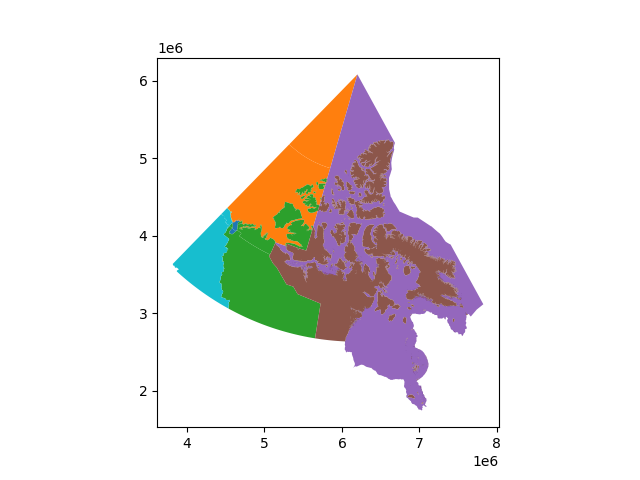

In [176]:
# CA_Water = gpd.read_file('source_data/boundary/lpr_000a21a_e.shp')
# CA_Water = CA_Water.loc[CA_Water['PRUID'].isin(['60','61','62'])].copy()
CA_Land = gpd.read_file('source_data/boundary/lpr_000b16a_e.shp')
# CA_Land = CA_Land.loc[CA_Land['PRUID'].isin(['60','61','62'])].to_crs(CA_Water.crs)
# Delta = gpd.read_file('source_data/boundary/delta.shp').to_crs(CA_Water.crs)
ISR = gpd.read_file('source_data/boundary/ISR_bounds.shp').to_crs(CA_Land.crs)
# Delta['Delta'] = True
# ISR['ISR'] = True
# CA_Land['Onshore'] = True
# TC = [ISR[['ISR','geometry']].copy(),Delta[['Delta','geometry']].copy(),CA_Land.loc[CA_Land['PRUID'].isin(['60','61','62']),['Onshore','geometry']].copy()]
# ROI = CA_Water[['PRUID','PRNAME','geometry']].copy()
# clp = CA_Water.dissolve()
# for t in TC:
#     t = t.clip(clp)
#     ROI = gpd.overlay(ROI,t,how='union',keep_geom_type=True)
# ROI = ROI.loc[ROI.area>1e6]
# # Create regions in line with nomenclature CER usues
# ROI['ISR'] = ROI['ISR'].fillna(False)
# ROI['Delta'] = ROI['Delta'].fillna(False)
# ROI['Onshore'] = ROI['Onshore'].fillna(False)
# ROI['Region'] = 'NWT Offshore'
# ROI.loc[ROI['PRUID']=='60','Region'] = 'Yukon Offshore'
# ROI.loc[ROI['PRUID']=='62','Region'] = 'Nunavut Offshore'
# ROI.loc[ROI['Delta'] & ROI['Onshore'],'Region'] = ROI.loc[ROI['Delta'] & ROI['Onshore'],'Region'].str.replace('Offshore','Mackenzie Delta')
# ROI.loc[ROI['Onshore'],'Region'] = ROI.loc[ROI['Onshore'],'Region'].str.replace('Offshore','Onshore')
# ROI = ROI.dissolve(by=['Region','ISR']).reset_index()
# ROI.to_file('source_data/boundary/ROI.shp')
# Regions shapefile (created as above)
ROI = gpd.read_file('source_data/boundary/ROI.shp')
fig,ax=plt.subplots()
ROI.plot(ax=ax,column='Region')
print(ROI['Region'].unique())


In [ ]:

SynchronizedWells['Region'] = None
SynchronizedWells['ISR'] = None
CentrePoints = SynchronizedWells['NAD1983_centroid'].to_crs(ROI.crs)
for Region in ROI['Region'].unique():
    for isr in [True,False]:
        sel = ROI.loc[((ROI['Region']==Region)&(ROI['ISR']==isr))].geometry
        if len(sel):
            SynchronizedWells.loc[
                CentrePoints.within(sel.values[0]),'Region'
                ] = Region
            SynchronizedWells.loc[
                CentrePoints.within(sel.values[0]),'ISR'
                ] = isr
SynchronizedWells.loc[((SynchronizedWells['NAD1983_centroid'].y<72)&(
    (SynchronizedWells['Region'] == 'NWT Offshore')|
    (SynchronizedWells['Region'] == 'Yukon Offshore'))),'Region'] = 'Beaufort Sea'
SynchronizedWells.loc[((SynchronizedWells['NAD1983_centroid'].y>72)&(SynchronizedWells['Region'] == 'NWT Offshore')),'Region'] = 'NWT Arctic Islands Onshore'
SynchronizedWells.loc[((SynchronizedWells['NAD1983_centroid'].y>72)&(SynchronizedWells['Region'] == 'NWT Onshore')),'Region'] = 'NWT Arctic Islands Offshore'
SynchronizedWells.groupby(['Region','ISR']).count()['Name']


Region                      ISR  
Beaufort Sea                True      104
NWT Arctic Islands Onshore  True       42
NWT Mackenzie Delta         False       4
                            True       55
NWT Offshore                True       11
NWT Onshore                 False    1069
                            True      131
Nunavut Offshore            False      33
Nunavut Onshore             False      92
Yukon Onshore               False      91
                            True        7
Name: Name, dtype: int64

Text(0.5, 1.0, 'Well Center Points')

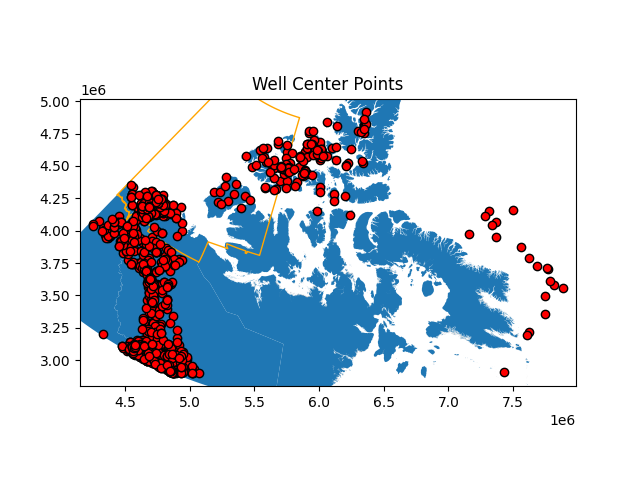

In [154]:
fig,ax=plt.subplots()
CA_Land.plot(ax=ax)
ISR.plot(ax=ax,color='None',edgecolor='orange')
CentrePoints.to_crs(CA_Land.crs).plot(ax=ax,color='red',edgecolor='k')
blim = CentrePoints.buffer(1e5).total_bounds
ax.set_xlim(blim[0],blim[2])
ax.set_ylim(blim[1],blim[3])
ax.set_title('Well Center Points')

In [155]:
dest = '../LeakingWellSites/data'
SynchronizedWells['NAD1983_centroid'] = SynchronizedWells['NAD1983_centroid'].to_wkt()
for p in [os.getcwd(),dest]:
    if p is not None and os.path.isdir(p):
        out = os.path.join(p,'NorthernWellSites.json')
        if os.path.isfile(out):
            os.remove(out)
        SynchronizedWells.to_file(out,driver='geojson')

In [157]:
SynchronizedWells['Region'].unique()

array(['NWT Onshore', 'Nunavut Onshore', 'NWT Offshore', None,
       'Yukon Onshore', 'NWT Mackenzie Delta', 'Nunavut Offshore'],
      dtype=object)

regroup by UWI